# Entropie croisée, interprétation géométrique, et implémentation

CSI 4506 - automne 2026

Marcel Turcotte  
Version: août 9, 2026 11h52

# Préambule

## Message du jour

![](https://mobile-img.lpcdn.ca/v2/924x/r3996/3a58da97079634869db7907031d2f82a.webp)

[Intelligence artificielle: BYE-BYE VOTRE
EMPLOI?](https://www.lapresse.ca/contexte/intelligence-artificielle/bye-bye-votre-emploi/2025-09-21/des-emplois-disparus.php)
Un dossier de 6 articles publiés dans La Presse, 2025-09-21.

## Message du jour (suite)

<https://www.youtube.com/watch?v=I_cvKK7LanI>

[AI’s “Significant Effect” on Entry-Level
Work](https://www.youtube.com/watch?v=I_cvKK7LanI), TIME, 2025-09-05.
(13m 55s)

TIME a mené des entrevues avec les auteurs d’un rapport récent du
**Stanford Digital Economy Lab**, intitulé “Canaries in the Coal Mine?
Six Facts about the Recent Employment Effects of Artificial
Intelligence.” Le rapport est disponible
[ici](https://www.rivista.ai/wp-content/uploads/2025/09/1756729755699.pdf)
et voici le résumé :

> Cet article examine les changements sur le marché du travail pour les
> professions exposées à l’intelligence artificielle générative en
> utilisant des données administratives à haute fréquence du plus grand
> fournisseur de logiciel de paie aux États-Unis. Nous présentons six
> faits qui caractérisent ces changements. Nous constatons que depuis
> l’adoption généralisée de l’IA générative, les jeunes travailleurs en
> début de carrière (22-25 ans) dans les professions les plus exposées à
> l’IA ont connu un déclin relatif de 13 % de l’emploi même après avoir
> contrôlé les chocs au niveau de l’entreprise. En revanche, l’emploi
> pour les travailleurs dans des domaines moins exposés et les
> travailleurs plus expérimentés dans les mêmes professions est resté
> stable ou a continué de croître. Nous constatons également que les
> ajustements se produisent principalement par l’emploi plutôt que par
> la compensation. De plus, les déclins de l’emploi sont concentrés dans
> des professions où l’IA est plus susceptible d’automatiser, plutôt que
> d’augmenter, le travail humain. Nos résultats sont robustes à des
> explications alternatives, telles que l’exclusion des entreprises
> liées à la technologie et l’exclusion des professions propices au
> télétravail. Ces six faits fournissent des preuves précoces et à
> grande échelle cohérentes avec l’hypothèse que la révolution de l’IA
> commence à avoir un impact significatif et disproportionné sur les
> travailleurs de niveau débutant sur le marché du travail américain.

## Message du jour (suite)

<https://www.youtube.com/watch?v=p_kF_SDB0-c>

[How AI is changing the job
market](https://www.youtube.com/watch?v=p_kF_SDB0-c), What in the World
podcast, BBC World Service, 2025-09-16.

Une multitude de vidéos, d’articles de presse et de publications
académiques sont disponibles en ligne, explorant l’impact de
l’intelligence artificielle (IA) sur le marché de l’emploi. Notamment,
la source suivante offre une perspective plus optimiste, soulignant des
cas où les entreprises embauchent de plus en plus de jeunes diplômés
pour des postes seniors dans l’intention de leur fournir une formation
sur le tas.

- [How AI Is Crushing Junior Developers](https://youtu.be/106DaA8WdHg),
  Economy Media, publié le 2025-09-04.
- [Why It is So Difficult to Gen Zeers to Get a
  Job](https://www.youtube.com/watch?v=P4I_LuUqBqg), Economy Media,
  publié le 2025-10-01.

## Résultats d’apprentissage

À la fin de cette présentation, vous devriez être capable de :

- **Différencier** entre MSE et l’entropie croisée en tant que fonctions
  de perte.
- **Relier** l’estimation du maximum de vraisemblance à l’apprentissage
  des paramètres dans la régression logistique.
- **Interpréter** la vue géométrique de la régression logistique comme
  une frontière de décision linéaire.
- **Implémenter** la régression logistique avec la descente de gradient
  sur des données simples.

# Régression linéaire

## Problème

- **Cas général :** $P(y = k \mid x, \theta)$, où $k$ est une étiquette
  de classe.
- **Cas binaire :** $y \in \{0,1\}$
  - **Prédire** $P(y = 1 \mid x, \theta)$

Pour une nouvelle instance $x_{\textrm{new}}$, déterminez la probabilité
qu’elle appartienne à la classe $k$, notée
$P(y = k \mid x_{\textrm{new}}, \theta)$.

## Régression logistique

Le modèle de **régression logistique** est défini comme suit :

$$
  h_\theta(x_i) = \sigma(\theta x_i) = \frac{1}{1+e^{- \theta x_i}}
  $$

- Les **prédictions** sont effectuées comme suit :

- $y_i = 0$, si $h_\theta(x_i) < 0.5$

- $y_i = 1$, si $h_\theta(x_i) \geq 0.5$

Le problème est formulé comme une tâche de **classification binaire**,
où le modèle suppose que les classes sont séparables par une **fonction
linéaire** dans l’espace des attributs.

Lors du cours précédent, nous avons étudié un exemple où la **régression
logistique** était utilisée pour classer des **chiffres manuscrits**.

- Le problème de classification a été abordé en utilisant une stratégie
  **un-contre-tous**, impliquant l’entraînement de dix modèles de
  régression logistique séparés, chacun dédié à la reconnaissance d’un
  chiffre spécifique.
- Chaque modèle comprenait **65 paramètres** : un terme de **biais** et
  **64 poids**. Chaque **poids** correspondait à un **pixel** (ou
  **attribut**) d’une image de $64 \times 64$ pixels.
- Cette méthode a démontré une excellente performance, atteignant une
  précision globale de 0.97.
- L’analyse des poids a fourni des informations sur les zones de l’image
  auxquelles le modèle était le plus réactif (à quoi prête-t-il
  attention ?).

Le modèle présenté ci-dessus est exprimé sous sa forme vectorisée, lui
permettant d’être appliqué à des problèmes impliquant de multiples
attributs. Dans le contexte de la reconnaissance de chiffres manuscrits,
le modèle utilise 64 attributs, correspondant à des pixels individuels.
La fonction $\sigma$ utilisée dans ce modèle est la fonction logistique,
ou sigmoïde.

# Fonction de perte

## Aperçu du modèle

- Notre modèle est exprimé sous une forme vectorisée comme suit :

  $$
  h_\theta(x_i) = \sigma(\theta x_i) = \frac{1}{1+e^{- \theta x_i}}
  $$

- **Prédiction** :

  - Assigner $y_i = 0$, si $h_\theta(x_i) < 0.5$ ; $y_i = 1$, si
    $h_\theta(x_i) \geq 0.5$

- On trouve les valeurs optimales de $\theta$ avec la **descente de
  gradient**.

- Quelle **fonction de perte** devrait être utilisée et pourquoi ?

Dans la régression logistique, la sortie est considérée comme une
probabilité, avec une attention particulière sur le processus
d’interprétation.

## Remarques

- Lors de la construction de modèles d’apprentissage automatique avec
  des bibliothèques comme `scikit-learn` ou `keras`, il faut
  **sélectionner une fonction de perte** ou **accepter celle par
  défaut**.

- Initialement, la **terminologie peut être déroutante**, car des
  fonctions identiques peuvent être référencées par divers noms.

- Notre objectif est de **clarifier ces complexités**.

- Ce n’est en fait **pas si compliqué** !

## Estimation des paramètres

- La régression logistique est un **modèle statistique**.

- Sa sortie est $\hat{y} = P(y = 1 | x, \theta)$.

- $P(y = 0 | x, \theta) = 1 - \hat{y}$.

- Suppose que les valeurs de $y$ proviennent d’une **distribution de
  Bernoulli**.

- $\theta$ est généralement trouvé par **l’estimation du maximum de
  vraisemblance**.

Les expressions $\hat{y}$, $h_\theta(x_i)$, et $\sigma(\theta x_i)$
représentent le même concept, bien qu’à des niveaux d’abstraction et de
spécificité différents.

## Estimation des paramètres

**L’estimation par maximum de vraisemblance (MLE)** (*Maximum Likelihood
Estimation*) est une méthode statistique utilisée pour estimer les
paramètres d’un modèle probabiliste.

Elle identifie les valeurs des paramètres qui maximisent la **fonction
de vraisemblance**, qui évalue à quel point le modèle décrit les données
observées.

## Fonction de vraisemblance

En supposant que les valeurs de $y$ sont *indépendantes et identiquement
distribuées (i.i.d.)*, la **fonction de vraisemblance** est exprimée
comme le **produit des probabilités individuelles**.

En d’autres termes, étant donné nos données, $\{(x_i, y_i)\}_{i=1}^N$,
la fonction de vraisemblance est donnée par cette équation. $$
\mathcal{L}(\theta) = \prod_{i=1}^{N} P(y_i \mid x_i, \theta)
$$

## Maximum de vraisemblance

$$
  \hat{\theta} = \underset{\theta \in \Theta}{\arg \max} \mathcal{L}(\theta) =  \underset{\theta \in \Theta}{\arg \max}  \prod_{i=1}^{N} P(y_i \mid x_i, \theta)
$$

- **Observations** :

  1.  **Maximiser** une fonction équivaut à **minimiser son opposé.**
  2.  Le **logarithme d’un produit** équivaut à la **somme de ses
      logarithmes**.

## Vraisemblance logarithmique négative

**Vraisemblance maximale** $$
  \hat{\theta} = \underset{\theta \in \Theta}{\arg \max} \mathcal{L}(\theta) = \underset{\theta \in \Theta}{\arg \max}  \prod_{i=1}^{N} P(y_i \mid x_i, \theta)
$$

devient **vraisemblance logarithmique négative** (*negative
log-likelihood*)

$$
\hat{\theta} = \underset{\theta \in \Theta}{\arg \min} - \log \mathcal{L(\theta)} = \underset{\theta \in \Theta}{\arg \min} - \log \prod_{i=1}^{N} P(y_i \mid x_i, \theta) = \underset{\theta \in \Theta}{\arg \min} - \sum_{i=1}^{N} \log P(y_i \mid x_i, \theta)
$$

## Reformulation mathématique

Pour des résultats binaires, la probabilité $P(y \mid x, \theta)$ est :

$$
P(y \mid x, \theta) =
\begin{cases}
\sigma(\theta x), & \text{si}\ y = 1 \\
1 - \sigma(\theta x), & \text{si}\ y = 0
\end{cases}
$$

. . .

Cela peut être exprimé de manière compacte comme :

$$
P(y \mid x, \theta) = \sigma(\theta x)^y (1 - \sigma(\theta x))^{1-y}
$$

Ce **“tour de passe-passe mathématique”** valide la logique de
l’**encodage des étiquettes**.

## Fonction de perte

Nous sommes maintenant prêts à écrire notre **fonction de perte**.

$$
J(\theta) = - \log \mathcal{L(\theta)} = - \sum_{i=1}^{N} \log P(y_i \mid x_i, \theta)
$$ où
$P(y \mid x, \theta) = \sigma(\theta x)^y (1 - \sigma(\theta x))^{1-y}$.

Par conséquent, $$
J(\theta) = - \sum_{i=1}^{N} \log [ \sigma(\theta x_i)^{y_i} (1 - \sigma(\theta x_i))^{1-y_i} ]
$$

## Fonction de perte (suite)

Simplification de l’équation. $$
J(\theta) = - \sum_{i=1}^{N} \log [ \sigma(\theta x_i)^{y_i} (1 - \sigma(\theta x_i))^{1-y_i} ]
$$ en distribuant le $\log$ dans les crochets carrés. $$
J(\theta) = - \sum_{i=1}^{N} [ \log \sigma(\theta x_i)^{y_i} + \log (1 - \sigma(\theta x_i))^{1-y_i} ]
$$

## Fonction de perte (suite)

Simplification supplémentaire de l’équation. $$
J(\theta) = - \sum_{i=1}^{N} [ \log \sigma(\theta x_i)^{y_i} + \log (1 - \sigma(\theta x_i))^{1-y_i} ]
$$ en déplaçant les exposants devant les $\log$s.

$$
J(\theta) = - \sum_{i=1}^{N} [ y_i \log \sigma(\theta x_i) + (1-y_i) \log (1 - \sigma(\theta x_i)) ]
$$

La raison de ces simplifications supplémentaires sera expliquée sous
peu.

## Une chose de plus

- Les algorithmes des arbres de décision utilisent souvent
  l’**entropie**, une mesure issue de la **théorie de l’information**,
  pour évaluer la qualité des divisions ou des partitions dans les
  règles de décision.
- L’entropie quantifie l’incertitude ou l’impureté associée aux
  résultats potentiels d’une variable aléatoire.

## Entropie

L’**entropie** dans la théorie de l’information quantifie
l’**incertitude** ou l’imprévisibilité des résultats possibles d’une
variable aléatoire. Elle mesure la quantité moyenne d’information
produite par une source de données stochastique et est généralement
exprimée en bits pour les systèmes binaires. L’entropie $H$ d’une
variable aléatoire discrète $X$ avec des résultats possibles
$\{x_1, x_2, \ldots, x_n\}$ et une fonction de masse de probabilité
$P(X)$ est donnée par :

$$
H(X) = -\sum_{i=1}^n P(x_i) \log_2 P(x_i)
$$

## Entropie croisée

L’**entropie croisée** quantifie la **différence entre deux
distributions de probabilité**, typiquement la **distribution réelle**
et une **distribution prédite**.

$$
H(p, q) = -\sum_{i} p(x_i) \log q(x_i) 
$$ où $p(x_i)$ est la distribution de probabilité réelle, et $q(x_i)$
est la distribution de probabilité prédite.

## Entropie croisée

- Considérons $y$ comme la distribution de probabilité réelle et
  $\hat{y}$ comme la distribution de probabilité prédite.
- L’entropie croisée quantifie la **divergence** entre ces deux
  distributions.

## Entropie croisée

Considérons la fonction de **perte de log-vraisemblance négative**
(*negative log-likelihood*) :

$$
J(\theta) = - \sum_{i=1}^{N} \left[ y_i \log \sigma(\theta x_i) + (1-y_i) \log (1 - \sigma(\theta x_i)) \right]
$$

En remplaçant $\sigma(\theta x_i)$ par $\hat{y_i}$, la fonction devient
:

$$
J(\theta) = - \sum_{i=1}^{N} \left[ y_i \log \hat{y_i} + (1-y_i) \log (1 - \hat{y_i}) \right]
$$

Cette expression illustre que la **log-vraisemblance négative** est
optimisée en minimisant l’**entropie croisée**.

**Cross-entropy**, **log loss**, et **negative log-likelihood** se
réfèrent au même concept.

Interprétez l’équation finale comme s’appliquant à tous les exemples de
1 à $N$ et à toutes les classes de 1 à $k$. Ici, $k=0$ car nous traitons
un problème de classification binaire.

## Exemple

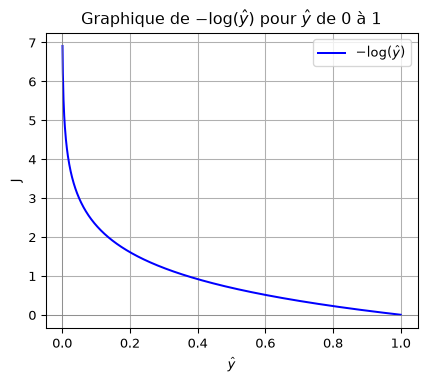

In [1]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)

# Générer un tableau de valeurs p allant juste au-dessus de 0 jusqu'à 1
p_values = np.linspace(0.001, 1, 1000)

# Calculer le logarithme naturel de chaque valeur p
ln_p_values = - np.log(p_values)

# Tracer le graphique
plt.figure(figsize=(5, 4))
plt.plot(p_values, ln_p_values, label=r'$-\log(\hat{y})$', color='b')

# Ajouter des étiquettes et un titre
plt.xlabel(r'$\hat{y}$')
plt.ylabel(r'J')
plt.title(r'Graphique de $-\log(\hat{y})$ pour $\hat{y}$ de 0 à 1')
plt.grid(True)
plt.axhline(0, color='gray', lw=0.5)  # Ajouter une ligne horizontale à y=0
plt.axvline(0, color='gray', lw=0.5)  # Ajouter une ligne verticale à x=0

# Afficher le graphique
plt.legend()
plt.show()

$$
J(\theta) = - \sum_{i=1}^{N} \left[ y_i \log \hat{y_i} + (1-y_i) \log (1 - \hat{y_i}) \right]
$$

Pour chaque exemple :

- Un seul des deux termes dans la sommation n’est pas nul.
- $1 - \hat{y_i}$ est $P(y = 0 \mid x, \theta)$.
- Lorsque $\hat{y_i}$ tend vers 1.0, $- \log(\hat{y})$ tend vers zéro.
- Lorsque $\hat{y_i}$ tend vers 0.0, indiquant une prédiction
  incorrecte, $- \log(\hat{y})$ tend vers $\infty$.
- Cette pénalité substantielle permet à la perte d’entropie croisée de
  converger plus rapidement que l’erreur quadratique moyenne.

## Remarques

- La perte d’entropie croisée est particulièrement bien adaptée aux
  **tâches de classification probabilistes** en raison de son alignement
  avec l’estimation du maximum de vraisemblance.

- Dans la régression logistique, la **perte d’entropie croisée préserve
  la convexité**, contrastant avec la nature non convexe de l’erreur
  quadratique moyenne (MSE)[1].

Nous revisiterons la perte d’entropie croisée lors de l’étude de
l’apprentissage profond, en particulier en conjonction avec la fonction
softmax.

Si vous entraînez une **régression logistique** avec la perte de
**l’erreur quadratique moyenne (MSE)** :

- La composition du **sigmoïde** (non linéaire, en forme de S) avec la
  **perte quadratique** produit un **objectif non convexe**.
- Cela conduit à de multiples minima locaux et à un comportement
  d’optimisation médiocre.
- En revanche, l’utilisation de la **log-perte (entropie croisée)**
  donne un **objectif convexe** par rapport aux paramètres, rendant
  l’optimisation bien comportée avec les méthodes de gradient.

## Remarques

- Pour les problèmes de classification, la perte d’entropie croisée
  atteint souvent une **convergence plus rapide** comparée à la MSE,
  améliorant l’efficacité du modèle.

- Dans les architectures d’apprentissage profond, la MSE peut exacerber
  le **problème de gradient évanescent**, une question que nous
  aborderons dans une discussion ultérieure.

## Pourquoi ne pas utiliser la MSE comme fonction de perte ?

<https://www.youtube.com/watch?v=m0ZeT1EWjjI>

## Quelle est la différence ?

<https://www.youtube.com/watch?v=ziq967YrSsc>

# Interprétation géométrique

## Interprétation géométrique

- **Reconnaissez-vous** cette équation ? $$
  w_1 x_1 + w_2 x_2 + \ldots + w_D x_2
  $$

- C’est le **produit scalaire** de $\mathbf{w}$ et $\mathbf{x}$,
  $\mathbf{w} \cdot \mathbf{x}$.

- Quelle est l’**interprétation géométrique** du produit scalaire ?

. . .

$$
\mathbf{w} \cdot \mathbf{x} = \|\mathbf{w}\| \|\mathbf{x}\| \cos \theta
$$

Dans certains contextes, il est avantageux d’utiliser $w$ à la place de
$\theta$.

## Interprétation géométrique

$$
\mathbf{w} \cdot \mathbf{x} = \|\mathbf{w}\| \|\mathbf{x}\| \cos \theta
$$

- Le **produit scalaire** détermine l’**angle $(\theta)$ entre les
  vecteurs**.

- Il **quantifie** combien un vecteur s’étend dans la direction d’un
  autre.

- Sa valeur est zéro, si les vecteurs sont **perpendiculaires**
  $(\theta = 90^\circ)$.

## Interprétation géométrique

- La **régression logistique** utilise une combinaison linéaire des
  attributs d’entrée, $\mathbf{w} \cdot \mathbf{x} + b$, comme argument
  pour la fonction sigmoïde (logistique).

- Géométriquement, $\mathbf{w}$ peut être vu comme un **vecteur normal à
  un hyperplan dans l’espace des attributs**, et tout point $\mathbf{x}$
  est projeté sur $\mathbf{w}$ via le produit scalaire
  $\mathbf{w} \cdot \mathbf{x}$.

## Interprétation géométrique

- La **frontière de décision** est là où cette combinaison linéaire est
  égale à zéro, c’est-à-dire $\mathbf{w} \cdot \mathbf{x} + b = 0$.

- Les points d’un côté de la frontière ont un **produit scalaire
  positif** et sont plus susceptibles d’être classés dans la classe
  positive (1).

- Les points de l’autre côté ont un **produit scalaire négatif** et sont
  plus susceptibles d’être dans la classe opposée (0).

- La **fonction sigmoïde** convertit simplement cette **distance
  signée** en une **probabilité** entre 0 et 1.

## Fonction logistique

$$
  \sigma(t) = \frac{1}{1+e^{-t}}
$$

- Lorsque $t \to \infty$, $e^{-t} \to 0$, donc $\sigma(t) \to 1$.
- Lorsque $t \to -\infty$, $e^{-t} \to \infty$, ce qui fait que le
  dénominateur tend vers l’infini, donc $\sigma(t) \to 0$.
- Quand $t = 0$, $e^{-t} = 0$, ce qui donne un dénominateur de 2, donc
  $\sigma(t) = 0.5$.

``` python
# Fonction sigmoïde
def sigmoid(t):
    return 1 / (1 + np.exp(-t))

# Générer des valeurs de t
t = np.linspace(-6, 6, 1000)

# Calculer les valeurs de y pour la fonction sigmoïde
sigma = sigmoid(t)

# Créer une figure
fig, ax = plt.subplots()
ax.plot(t, sigma, color='blue', linewidth=2)  # Garder la courbe opaque

# Tracer l'axe vertical à x = 0
ax.axvline(x=0, color='black', linewidth=1)

# Ajouter des étiquettes sur l'axe vertical
ax.set_yticks([0, 0.5, 1.0])

# Ajouter des étiquettes aux axes
ax.set_xlabel('t')
ax.set_ylabel(r'$\sigma(t)$')

plt.grid(True)
plt.show()
```

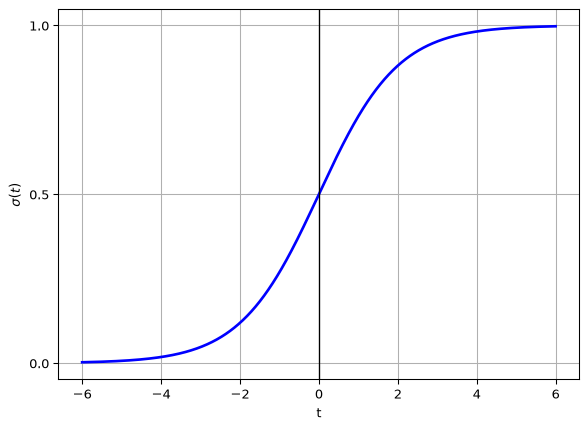

## Pourquoi e ?

$$
  \sigma(t) = \frac{1}{1+e^{-t}}
$$

- Au lieu de $e$, nous aurions pu utiliser une autre constante, disons
  2.

- **Simplicité de la dérivée** : Pour la fonction logistique
  $\sigma(x) = \tfrac{1}{1 + e^{-x}}$, la dérivée se simplifie à
  $\sigma'(x) = \sigma(x)(1 - \sigma(x))$. Cette forme élégante apparaît
  parce que la base exponentielle $e$ a la propriété unique que
  $\tfrac{d}{dx} e^x = e^x$, évitant une constante multiplicative
  supplémentaire.

``` python
import math

def logistic(x, e):
    """Calcule une fonction logistique modifiée utilisant b au lieu de e."""
    return 1 / (1 + np.power(e, -x))

# Définir une plage de valeurs pour x.
x = np.linspace(-6, 6, 400)

# Graphique 1 : Variation de e.
plt.figure(figsize=(8, 6))
e_values = [2, math.e, 4, 8, 16]  # différentes valeurs de pente

for e in e_values:
    plt.plot(x, logistic(x, e), label=f'e = {e}')
plt.title('Effet de la variation de e')
plt.xlabel('x')
plt.ylabel(r'$\frac{1}{1+e^{-x}}$')
plt.legend()
plt.grid(True)
```

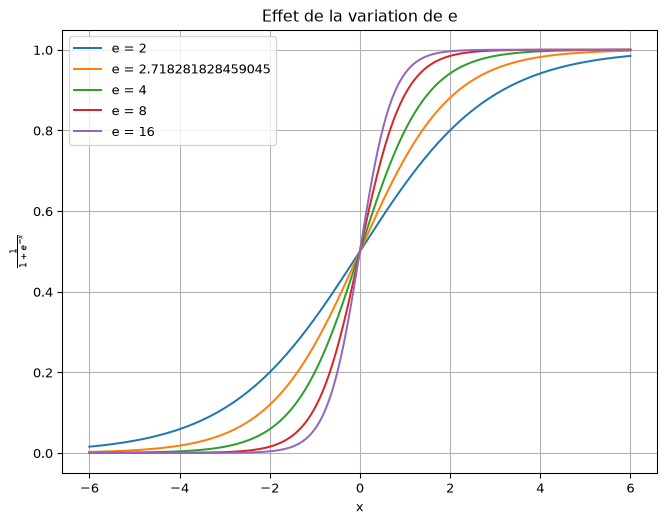

Dans le contexte de la régression logistique, le choix de la constante
mathématique $e$ n’est pas arbitraire mais est soutenu par plusieurs
justifications mathématiques convaincantes. Ces justifications
concernent principalement l’intégration harmonieuse de la fonction
logistique avec d’autres cadres mathématiques. Bien que notre objectif
principal soit de démontrer visuellement les implications potentielles
de la substitution d’une autre constante, les avantages inhérents à
l’utilisation de $e$ deviennent évidents lorsque l’on examine de plus
près ses propriétés mathématiques et comment elles facilitent une
intégration sans faille avec les théories et modèles existants.

## Variation de w

$$
  \sigma(wx + b)
$$

``` python
def logistic(x, w, b):
    """Calcule la fonction logistique avec les paramètres w et b."""
    return 1 / (1 + np.exp(-(w * x + b)))

# Définir un intervalle pour les valeurs de x.
x = np.linspace(-10, 10, 400)

# Graphique 1 : Variation de w (pente) avec b fixé à 0.
plt.figure(figsize=(8, 6))
w_values = [0.5, 1, 2, 5]  # différentes valeurs de pente
b = 0  # biais fixe

for w in w_values:
    plt.plot(x, logistic(x, w, b), label=f'w = {w}, b = {b}')
plt.title('Effet de la variation de w (avec b = 0)')
plt.xlabel('x')
plt.ylabel(r'$\sigma(wx+b)$')
plt.legend()
plt.grid(True)
plt.show()
```

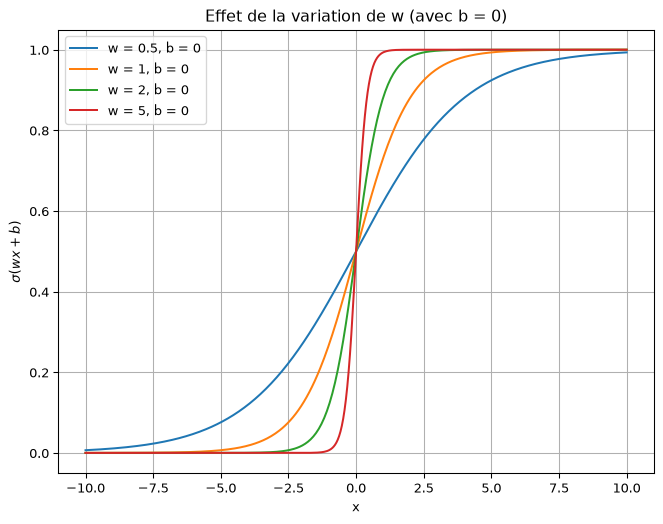

## Variation de b

$$
  \sigma(wx + b)
$$

``` python
# Graphique 2 : Variation de b (décalage horizontal) avec w fixé à 1.
plt.figure(figsize=(8, 6))
w = 1  # pente fixe
b_values = [-5, -2, 0, 2, 5]  # différentes valeurs de biais

for b in b_values:
    plt.plot(x, logistic(x, w, b), label=f'w = {w}, b = {b}')
plt.title('Effet de la variation de b (avec w = 1)')
plt.xlabel('x')
plt.ylabel(r'$\sigma(wx+b)$')
plt.legend()
plt.grid(True)

plt.show()
```

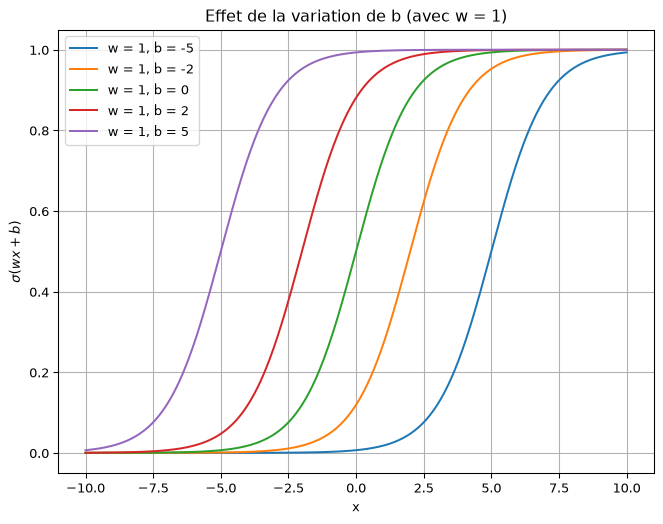

# Implémentation

## Génération de données

[1] Dans la régression linéaire, la perte de l’erreur quadratique
moyenne est convexe.

In [6]:
# Générer des données synthétiques pour un problème de classification binaire

m = 100  # nombre d'exemples
d = 2    # nombre d'attributs

X = np.random.randn(m, d)

# Définir les étiquettes en utilisant une frontière de décision linéaire avec un peu de bruit :

noise = 0.5 * np.random.randn(m)

y = (X[:, 0] + X[:, 1] + noise > 0).astype(int)

## Visualisation

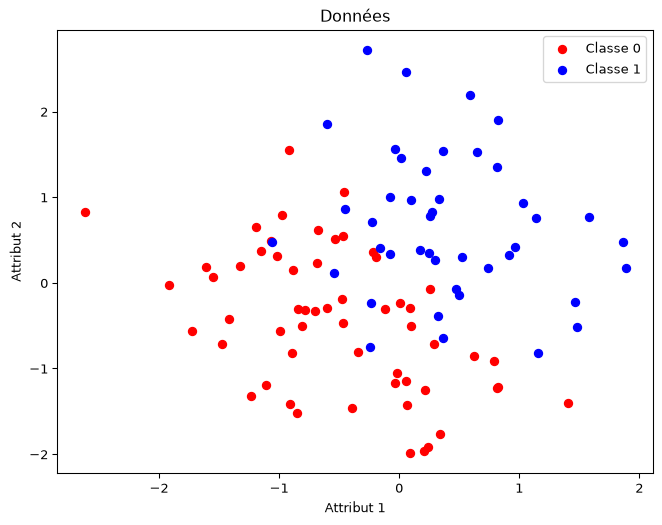

In [7]:
# Visualiser la frontière de décision avec les points de données
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Classe 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Classe 1')

plt.xlabel("Attribut 1")
plt.ylabel("Attribut 2")
plt.title("Données")
plt.legend()
plt.show()

## Fonction de coût

In [8]:
# Fonction Sigmoïde
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Fonction de coût : entropie croisée binaire
def cost_function(theta, X, y):
    m = len(y)
    h = sigmoid(X.dot(theta))
    epsilon = 1e-5  # éviter log(0)
    coût = -(1/m) * np.sum(y * np.log(h + epsilon) + (1 - y) * np.log(1 - h + epsilon))
    return coût

# Gradient de la fonction de coût
def gradient(theta, X, y):
    m = len(y)
    h = sigmoid(X.dot(theta))
    grad = (1/m) * X.T.dot(h - y)
    return grad

## Régression logistique

In [9]:
# Entraînement de la régression logistique par descente de gradient
def logistic_regression(X, y, learning_rate=0.1, iterations=1000):
    m, n = X.shape
    theta = np.zeros(n)
    historique_des_coûts = []
    
    for i in range(iterations):
        theta -= learning_rate * gradient(theta, X, y)
        historique_des_coûts.append(cost_function(theta, X, y))
        
    return theta, historique_des_coûts

## Entraînement

In [10]:
# Ajouter le terme d'interception (biais)
X_avec_interception = np.hstack([np.ones((m, 1)), X])

# Entraîner le modèle de régression logistique
theta, cost_history = logistic_regression(X_avec_interception, y, learning_rate=0.1, iterations=1000)

print("Theta optimisé :", theta)

Theta optimisé : [-0.28840995  2.80390104  2.45238752]

## Convergence de la fonction de coût

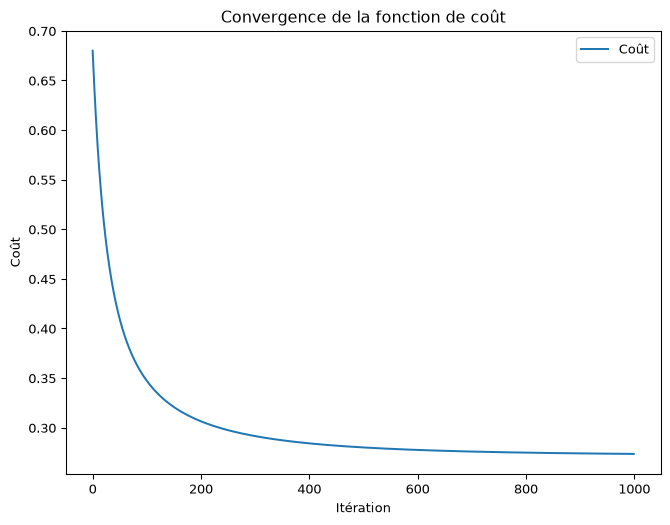

In [11]:
plt.figure(figsize=(8, 6))
plt.plot(cost_history, label="Coût")
plt.xlabel("Itération")
plt.ylabel("Coût")
plt.title("Convergence de la fonction de coût")
plt.legend()
plt.show()

## Frontière de décision

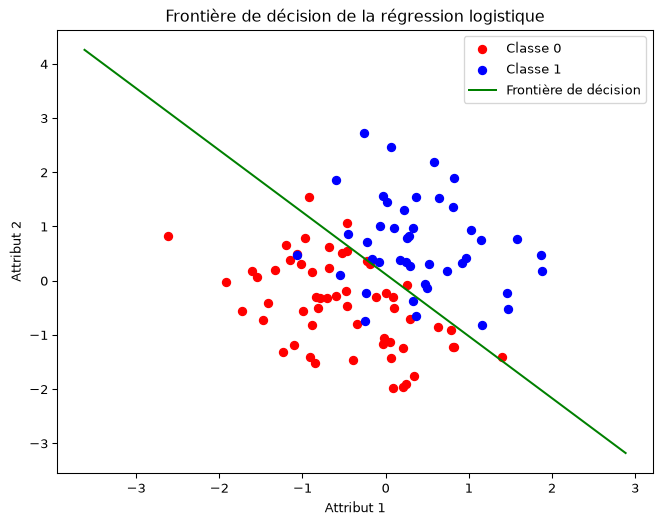

In [12]:
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Classe 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Classe 1')

# Frontière de décision : theta0 + theta1*x1 + theta2*x2 = 0
x_vals = np.array([min(X[:, 0]) - 1, max(X[:, 0]) + 1])
y_vals = -(theta[0] + theta[1] * x_vals) / theta[2]
plt.plot(x_vals, y_vals, label='Frontière de décision', color='green')
plt.xlabel("Attribut 1")
plt.ylabel("Attribut 2")
plt.title("Frontière de décision de la régression logistique")
plt.legend()
plt.show()

## Implémentation (suite)

In [13]:
# Fonction de prédiction : retourne les étiquettes de classe et les probabilités pour de nouvelles données
def predict(theta, X, threshold=0.5):
    probs = sigmoid(X.dot(theta))
    return (probs >= threshold).astype(int), probs

## Prédictions

In [14]:
# Les nouveaux exemples doivent inclure le terme d'interception.

# Exemple négatif (probablement classe 0) : Choisir un point loin dans le quadrant négatif.
example_neg = np.array([1, -3, -3])

# Exemple positif (probablement classe 1) : Choisir un point loin dans le quadrant positif.
example_pos = np.array([1, 3, 3])

# Près de la frontière de décision : Choisir x1 = 0 et calculer x2 à partir de l'équation de la frontière de décision.
x1_near = 0
x2_near = -(theta[0] + theta[1] * x1_near) / theta[2]
example_near = np.array([1, x1_near, x2_near])

Dans l’exemple donné, chaque point de données est caractérisé par deux
attributs principaux. Cependant, la représentation inclut trois
composants. Pourquoi ?

Cette divergence provient d’une technique mathématique discutée
antérieurement, où chaque instance est augmentée avec un terme
supplémentaire, $x_i^{(0)} = 1$. Cette augmentation facilite
l’expression du modèle dans un format vectorisé, améliorant l’efficacité
et la simplicité computationnelles.

## Prédictions (suite)

In [15]:
# Combiner les exemples en un seul tableau pour la prédiction.
new_examples = np.vstack([example_neg, example_pos, example_near])

labels, probabilities = predict(theta, new_examples)

print("\nPrédictions sur de nouveaux exemples:")

print("Exemple négatif {} -> Prédiction : {} (Probabilité : {:.4f})".format(example_neg[1:], labels[0], probabilities[0]))

print("Exemple positif {} -> Prédiction : {} (Probabilité : {:.4f})".format(example_pos[1:], labels[1], probabilities[1]))

print("Exemple près de la frontière {} -> Prédiction : {} (Probabilité : {:.4f})".format(example_near[1:], labels[2], probabilities[2]))


Prédictions sur de nouveaux exemples:
Exemple négatif [-3 -3] -> Prédiction : 0 (Probabilité : 0.0000)
Exemple positif [3 3] -> Prédiction : 1 (Probabilité : 1.0000)
Exemple près de la frontière [0.         0.11760374] -> Prédiction : 1 (Probabilité : 0.5000)

## Visualisation du vecteur de poids

Lors du cours précédent, nous avons établi que la **régression
logistique** détermine un **vecteur de poids** qui est **orthogonal** à
la **frontière de décision**.

Inversement, la **frontière de décision** elle-même est **orthogonale**
au **vecteur de poids**, qui est dérivé par l’optimisation par descente
de gradient.

## Visualisation du vecteur de poids

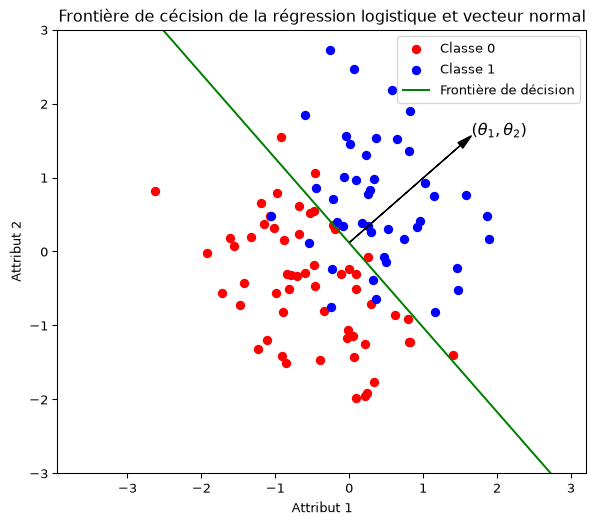

In [16]:
# Tracer la frontière de décision et les points de données
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Classe 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Classe 1')

# Frontière de décision : theta0 + theta1*x1 + theta2*x2 = 0
x_vals = np.array([min(X[:, 0]) - 1, max(X[:, 0]) + 1])
y_vals = -(theta[0] + theta[1] * x_vals) / theta[2]
plt.plot(x_vals, y_vals, label='Frontière de décision', color='green')

# --- Dessiner le vecteur normal ---
# Le vecteur normal est (theta[1], theta[2]).
# Choisir un point de référence sur la frontière de décision. Ici, nous utilisons x1 = 0 :
x_ref = 0
y_ref = -theta[0] / theta[2]  # quand x1=0, theta0 + theta2*x2=0  =>  x2=-theta0/theta2

# Créer le vecteur normal à partir de (theta[1], theta[2]).
normal = np.array([theta[1], theta[2]])

# Normaliser et ajuster pour l'affichage
normal_norm = np.linalg.norm(normal)
if normal_norm != 0:
    normal_unit = normal / normal_norm
else:
    normal_unit = normal
scale = 2  # ajuster l'échelle selon les besoins
normal_display = normal_unit * scale

# Dessiner une flèche en commençant au point de référence
plt.arrow(x_ref, y_ref, normal_display[0], normal_display[1],
          head_width=0.1, head_length=0.2, fc='black', ec='black')
plt.text(x_ref + normal_display[0]*1.1, y_ref + normal_display[1]*1.1, 
         r'$(\theta_1, \theta_2)$', color='black', fontsize=12)

plt.xlabel("Attribut 1")
plt.ylabel("Attribut 2")
plt.title("Frontière de cécision de la régression logistique et vecteur normal")
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.ylim(-3, 3)
plt.show()

## Près de la frontière de décision

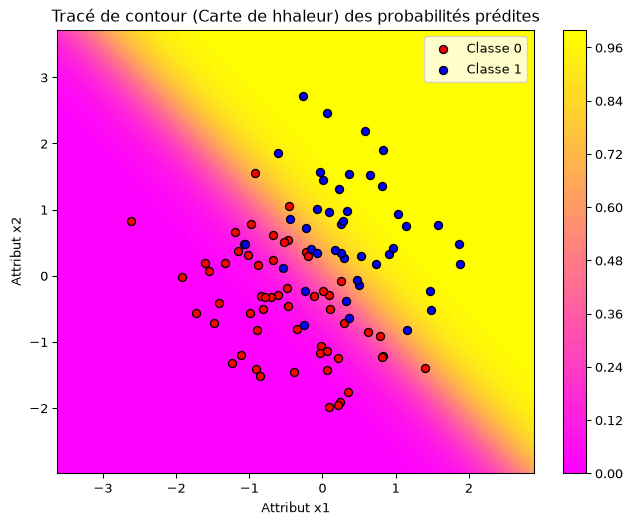

In [17]:
# --- Configuration de la Visualisation ---
# Créer une grille sur l'espace des attributs
x1_range = np.linspace(X[:, 0].min()-1, X[:, 0].max()+1, 100)
x2_range = np.linspace(X[:, 1].min()-1, X[:, 1].max()+1, 100)
xx1, xx2 = np.meshgrid(x1_range, x2_range)

# Construire l'entrée de la grille (avec interception) pour les prédictions
grid = np.c_[np.ones(xx1.ravel().shape), xx1.ravel(), xx2.ravel()]
# Calculer les probabilités prédites sur la grille
probs = sigmoid(grid.dot(theta)).reshape(xx1.shape)
# --- Approche 2 : Tracé de contour 2D (Carte de chaleur) ---
plt.figure(figsize=(8, 6))
contour = plt.contourf(xx1, xx2, probs, cmap='spring', levels=50)
plt.colorbar(contour)
plt.xlabel('Attribut x1')
plt.ylabel('Attribut x2')
plt.title('Tracé de contour (Carte de hhaleur) des probabilités prédites')
# Superposer les données d'entraînement
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', edgecolor='k', label='Classe 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', edgecolor='k', label='Classe 1')
plt.legend()
plt.show()

## Près de la frontière de décision

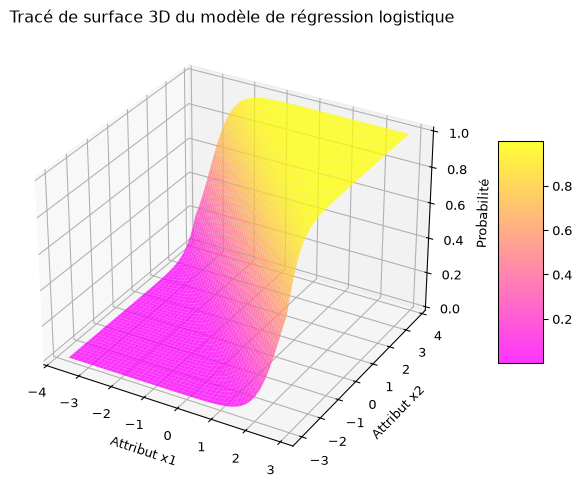

In [18]:
# --- Approche 1 : Tracé de Surface 3D ---
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='3d')
surface = ax.plot_surface(xx1, xx2, probs, cmap='spring', alpha=0.8)
ax.set_xlabel('Attribut x1')
ax.set_ylabel('Attribut x2')
ax.set_zlabel('Probabilité')
ax.set_title('Tracé de surface 3D du modèle de régression logistique')
fig.colorbar(surface, shrink=0.5, aspect=5)
plt.show()

# Prologue

## Résumé

Dans cette présentation, nous avons :

- Dérivé les formulations de la **vraisemblance** et de la
  **log-vraisemblance négative**.
- Illustré l’**interprétation géométrique** des frontières de décision
  et des vecteurs de poids.
- **Implémenté** la régression logistique avec la **descente de
  gradient** et visualisé les résultats.

## Prochain cours

- Évaluation des modèles

## Références

Russell, Stuart, et Peter Norvig. 2020. *Artificial Intelligence: A
Modern Approach*. 4ᵉ éd. Pearson. <http://aima.cs.berkeley.edu/>.

------------------------------------------------------------------------

Marcel **Turcotte**

<Marcel.Turcotte@uOttawa.ca>

École de **science informatique** et de génie électrique (**SI**GE)

Université d’Ottawa